# 🧠 Retrieval-Augmented Generation (RAG) for Document Question Answering

## 👨‍💻 Machine Learning Foundation – Week 7

### 🎯 Celebal Technologies Internship

---

# 📌 Project Objective

The objective of this project is to develop an end-to-end **Retrieval-Augmented Generation (RAG)** system capable of answering user questions based on the contents of a custom PDF document.

The system extracts textual information from a document, preprocesses and divides it into meaningful chunks, converts those chunks into semantic vector embeddings, stores them inside a FAISS vector database, retrieves the most relevant information for a given user query, and finally generates context-aware answers using a Large Language Model (LLM).

This project demonstrates practical implementation of semantic search, vector databases, embeddings, document retrieval, and Retrieval-Augmented Generation for document-based question answering systems.

# 📊 Executive Summary

Retrieval-Augmented Generation (RAG) is one of the most powerful techniques used in modern Artificial Intelligence systems to improve the accuracy of Large Language Models.

Traditional language models rely only on their pre-trained knowledge, whereas RAG systems first retrieve relevant information from external documents before generating an answer. This significantly improves factual accuracy and enables question answering over custom or private documents.

In this project, a PDF document is processed through a complete RAG pipeline involving document ingestion, text preprocessing, intelligent chunking, embedding generation using Sentence Transformers, semantic search through a FAISS vector database, and answer generation using a Large Language Model.

The developed system demonstrates how retrieval and generation work together to provide grounded, explainable, and context-aware responses.

# 📖 Understanding Retrieval-Augmented Generation (RAG)

Retrieval-Augmented Generation (RAG) is an AI architecture that combines **Information Retrieval** with **Large Language Models (LLMs)**.

Unlike traditional chatbots, a RAG system first searches an external knowledge source to retrieve relevant information before generating an answer.

This retrieval-first approach helps reduce hallucinations, improves factual accuracy, and enables AI systems to answer questions based on custom documents such as PDFs, research papers, reports, manuals, and enterprise knowledge bases.

Today, RAG is widely used in AI-powered search engines, enterprise assistants, customer support systems, legal document analysis, healthcare documentation, and educational platforms.

# 🔑 Core Components of a RAG System

## 1️⃣ Retrieval

Retrieval identifies the most relevant document chunks using semantic similarity between the user query and document embeddings.

---

## 2️⃣ Augmentation

The retrieved document chunks are combined with the user's question to provide contextual information to the language model.

---

## 3️⃣ Generation

The language model generates a final answer using the retrieved context, ensuring responses remain grounded in the source document instead of relying only on its internal knowledge.

# 🏗️ RAG Pipeline Architecture


```text
                         PDF Document
                               │
                               ▼
                     Document Ingestion
                               │
                               ▼
                      Text Extraction
                               │
                               ▼
                    Text Preprocessing
                               │
                               ▼
                 Intelligent Text Chunking
                               │
                               ▼
        Sentence Transformer Embedding Model
                               │
                               ▼
                  FAISS Vector Database
                               │
                               ▼
                      User Question
                               │
                               ▼
                 Query Embedding Generation
                               │
                               ▼
                Retrieve Top-k Relevant Chunks
                               │
                               ▼
            Retrieved Context + User Question
                               │
                               ▼
                  Large Language Model (LLM)
                               │
                               ▼
                Context-Aware Final Answer
```

# 🔄 Project Workflow

The complete workflow followed in this project is:

1. Load the PDF document.
2. Extract textual content from the document.
3. Clean and preprocess the extracted text.
4. Split the text into overlapping chunks.
5. Generate dense vector embeddings using Sentence Transformers.
6. Store embeddings inside a FAISS vector database.
7. Accept a user question.
8. Convert the user query into an embedding.
9. Retrieve the most relevant document chunks.
10. Pass the retrieved context to the language model.
11. Generate a context-aware answer.
12. Display the final response.

# 📚 Install Required Libraries

In [70]:
!pip -q install sentence-transformers
!pip -q install faiss-cpu
!pip -q install transformers
!pip -q install accelerate
!pip -q install pypdf

# 📦 Import Required Libraries

In [71]:
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pypdf import PdfReader

from sentence_transformers import SentenceTransformer

import faiss

from transformers import pipeline

warnings.filterwarnings("ignore")

print("="*50)
print("Libraries Imported Successfully")
print("="*50)

Libraries Imported Successfully


# 📂 Load the PDF Document

In [72]:
pdf_path = "Week7_Project.pdf"

reader = PdfReader(pdf_path)

print(f"Total Pages : {len(reader.pages)}")

Total Pages : 4


# 📖 Extract Text from PDF

In [73]:
# Extract text from all pages

document_text = ""

for page_num, page in enumerate(reader.pages):

    page_text = page.extract_text()

    if page_text:
        document_text += page_text + "\n"

print("Text extraction completed successfully.")

Text extraction completed successfully.


# 👀 Preview Extracted Text

In [74]:
print(document_text[:3000])

Document  Question  Answering  System  (RAG)  
Dataset:  
Simple  Beginner  Dataset  (Easiest)  
Use  your  own  PDFs:  
●  Notes  ●  Resume  ●  Research  papers  ●  Books  ●  RAG  is  meant  for  custom/private  data  
Or  Try  this  Hugging  Face  Dataset 
Reference:Github  Link   
Overview  
This  project  implements  a  Retrieval-Augmented  Generation  (RAG)  system  that  
answers
 
questions
 
based
 
on
 
custom
 
documents.
 
Instead  of  relying  only  on  a  language  model’s  internal  knowledge,  the  system  
retrieves
 
relevant
 
information
 
from
 
documents
 
and
 
then
 
generates
 
answers
 
grounded
 
in
 
that
 
information.
 
This
 
improves
 
factual
 
accuracy
 
and
 
allows
 
question
 
answering
 
over
 
private
 
or
 
domain-specific
 
data.
 
Objectives  
●  Understand  the  concept  of  Retrieval-Augmented  Generation  (RAG)  ●  Build  a  pipeline  combining  retrieval  and  generation  ●  Enable  question  answering  over  custom  documents  such  as  PDF

# 🧹 Text Preprocessing

In [75]:
# Remove unnecessary spaces and newlines

clean_text = re.sub(r"\s+", " ", document_text)

clean_text = clean_text.strip()

print("Text preprocessing completed.")

Text preprocessing completed.


# 📊 Document Statistics

In [76]:
num_characters = len(clean_text)

num_words = len(clean_text.split())

num_sentences = len(re.findall(r'[.!?]+', clean_text))

print("="*45)
print(f"Characters : {num_characters}")
print(f"Words      : {num_words}")
print(f"Sentences  : {num_sentences}")
print("="*45)

Characters : 3461
Words      : 514
Sentences  : 35


# 📈 Visualize Document Statistics

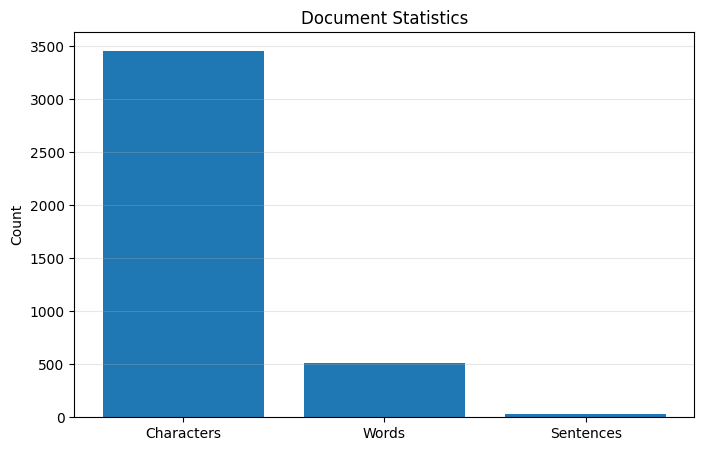

In [77]:
labels = ["Characters", "Words", "Sentences"]

values = [num_characters, num_words, num_sentences]

plt.figure(figsize=(8,5))

plt.bar(labels, values)

plt.title("Document Statistics")

plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ✂️ Intelligent Text Chunking

## 📌 Chunking Strategy

The document is divided into **overlapping text chunks** before generating embeddings.

Using overlapping chunks helps preserve contextual continuity across chunk boundaries and improves retrieval quality during semantic search.

**Chunk Size:** 500 characters

**Chunk Overlap:** 100 characters

This strategy balances retrieval accuracy and computational efficiency.

In [78]:
chunk_size = 500

overlap = 100

chunks = []

start = 0

while start < len(clean_text):

    end = start + chunk_size

    chunks.append(clean_text[start:end])

    start += chunk_size - overlap

print(f"Total Chunks Created : {len(chunks)}")

Total Chunks Created : 9


# 👀 Preview Text Chunks

In [79]:
for i in range(min(3, len(chunks))):

    print("="*80)

    print(f"Chunk {i+1}\n")

    print(chunks[i])

    print("\n")

Chunk 1

Document Question Answering System (RAG) Dataset: Simple Beginner Dataset (Easiest) Use your own PDFs: ● Notes ● Resume ● Research papers ● Books ● RAG is meant for custom/private data Or Try this Hugging Face Dataset Reference:Github Link Overview This project implements a Retrieval-Augmented Generation (RAG) system that answers questions based on custom documents. Instead of relying only on a language model’s internal knowledge, the system retrieves relevant information from documents and then


Chunk 2

nguage model’s internal knowledge, the system retrieves relevant information from documents and then generates answers grounded in that information. This improves factual accuracy and allows question answering over private or domain-specific data. Objectives ● Understand the concept of Retrieval-Augmented Generation (RAG) ● Build a pipeline combining retrieval and generation ● Enable question answering over custom documents such as PDFs or text files ● Learn how modern AI sy

# 📊 Chunk Statistics

In [80]:
chunk_lengths = [len(chunk) for chunk in chunks]

print(f"Average Chunk Length : {np.mean(chunk_lengths):.2f}")

print(f"Minimum Chunk Length : {np.min(chunk_lengths)}")

print(f"Maximum Chunk Length : {np.max(chunk_lengths)}")

Average Chunk Length : 473.44
Minimum Chunk Length : 261
Maximum Chunk Length : 500


# 📈 Chunk Length Distribution

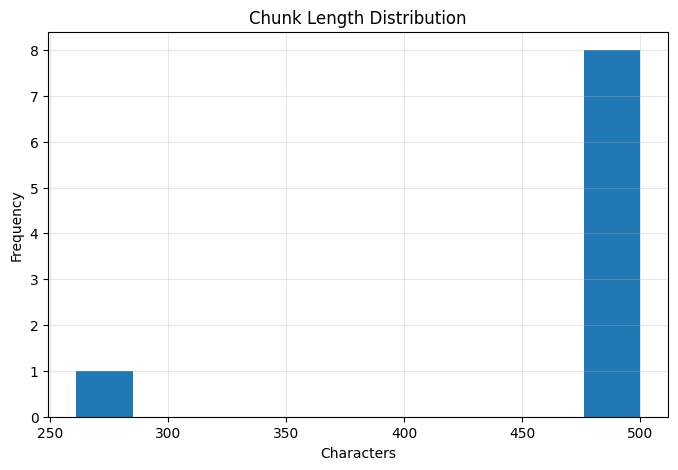

In [81]:
plt.figure(figsize=(8,5))

plt.hist(chunk_lengths, bins=10)

plt.title("Chunk Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# 🧠 Load Sentence Transformer Embedding Model

## 📌 Embedding Model Selection

To convert text chunks into dense vector representations, we use the **SentenceTransformer** model **all-MiniLM-L6-v2**.

### Why this model?

- Lightweight and fast
- Generates high-quality semantic embeddings
- Widely used in Retrieval-Augmented Generation (RAG) applications
- Suitable for semantic similarity search
- Efficient for CPU and Google Colab environments

The generated embeddings capture semantic meaning rather than simple keyword matching, improving retrieval accuracy.

In [82]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding Model Loaded Successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding Model Loaded Successfully!


# 🔢 Generate Text Embeddings

In [83]:
start_time = time.time()

chunk_embeddings = embedding_model.encode(
    chunks,
    show_progress_bar=True,
    convert_to_numpy=True
)

embedding_time = time.time() - start_time

print("="*50)

print("Embedding Generation Completed!")

print(f"Embedding Shape : {chunk_embeddings.shape}")

print(f"Time Taken : {embedding_time:.2f} seconds")

print("="*50)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding Generation Completed!
Embedding Shape : (9, 384)
Time Taken : 0.49 seconds


# 📊 Embedding Statistics

In [84]:
print(f"Number of Embeddings : {chunk_embeddings.shape[0]}")

print(f"Embedding Dimension : {chunk_embeddings.shape[1]}")

Number of Embeddings : 9
Embedding Dimension : 384


# 💾 Build FAISS Vector Database

## 📌 Why FAISS?

FAISS (Facebook AI Similarity Search) is an efficient vector database designed for fast similarity search over high-dimensional embeddings.

It enables the Retrieval-Augmented Generation (RAG) pipeline to quickly identify the most relevant document chunks corresponding to a user's query.

In [85]:
dimension = chunk_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(chunk_embeddings)

print("="*50)

print("FAISS Index Created Successfully!")

print(f"Total Vectors Stored : {index.ntotal}")

print("="*50)

FAISS Index Created Successfully!
Total Vectors Stored : 9


# 📊 Vector Database Statistics

In [86]:
print(f"Vector Dimension : {dimension}")

print(f"Total Stored Vectors : {index.ntotal}")

print(f"FAISS Index Type : IndexFlatL2")

Vector Dimension : 384
Total Stored Vectors : 9
FAISS Index Type : IndexFlatL2


# 🔍 Semantic Retrieval

In [87]:
def retrieve_chunks(question, top_k=3):

    question_embedding = embedding_model.encode(
        [question],
        convert_to_numpy=True
    )

    distances, indices = index.search(question_embedding, top_k)

    retrieved_chunks = []

    for idx in indices[0]:
        retrieved_chunks.append(chunks[idx])

    return retrieved_chunks, distances[0]

# ❓ Test Semantic Search

In [88]:
sample_question = "What is Retrieval-Augmented Generation?"

retrieved_chunks, scores = retrieve_chunks(sample_question)

# 📄 Retrieved Chunks

In [89]:
for i, (chunk, score) in enumerate(zip(retrieved_chunks, scores), start=1):

    print("="*80)

    print(f"Retrieved Chunk {i}")

    print(f"Distance Score : {score:.4f}\n")

    print(chunk)

    print("\n")

Retrieved Chunk 1
Distance Score : 0.9376

nguage model’s internal knowledge, the system retrieves relevant information from documents and then generates answers grounded in that information. This improves factual accuracy and allows question answering over private or domain-specific data. Objectives ● Understand the concept of Retrieval-Augmented Generation (RAG) ● Build a pipeline combining retrieval and generation ● Enable question answering over custom documents such as PDFs or text files ● Learn how modern AI systems work internally


Retrieved Chunk 2
Distance Score : 1.1012

ering over custom documents such as PDFs or text files ● Learn how modern AI systems work internally Key Concepts 1. Retrieval Retrieval is responsible for finding the most relevant chunks of text from a document. It typically uses embeddings and vector similarity search. 2. Augmentation The retrieved content is added to the model’s input to provide context for answering. 3. Generation A language model gener

# 🤖 Load the Language Model

## 📌 Language Model Configuration

For answer generation, this project uses the **google/flan-t5-base** model from Hugging Face.

### Why FLAN-T5?

- Instruction-tuned language model
- Lightweight and suitable for Google Colab
- Produces concise and context-aware answers
- Well-suited for Retrieval-Augmented Generation (RAG)

The retrieved document chunks are combined with the user's question and passed to the language model to generate grounded responses.

In [90]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

print("FLAN-T5 Model Loaded Successfully!")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


FLAN-T5 Model Loaded Successfully!


# 🧠 Build the RAG Question Answering Function

In [91]:
def rag_answer(question, top_k=3):

    start_time = time.time()

    # Retrieve relevant chunks
    retrieved_chunks, scores = retrieve_chunks(question, top_k)

    context = "\n\n".join(retrieved_chunks)

    prompt = f"""
Context:
{context}

Question:
{question}

Answer:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=100
    )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    total_time = time.time() - start_time

    return answer, retrieved_chunks, scores, total_time

# ❓ Ask a Question

In [92]:
question = "What is Retrieval-Augmented Generation?"

answer, retrieved_chunks, scores, response_time = rag_answer(question)

print("="*100)

print("Question:\n")

print(question)

print("\n")

print("="*100)

print("Answer:\n")

print(answer)

print("\n")

print("="*100)

print(f"Response Time : {response_time:.2f} seconds")

Question:

What is Retrieval-Augmented Generation?


Answer:

Retrieval-Augmented Generation (RAG) is a system that combines retrieval and generation to provide context for answering questions.


Response Time : 11.33 seconds


# 📄 Retrieved Context

In [93]:
for i, chunk in enumerate(retrieved_chunks):

    print("="*80)

    print(f"Retrieved Chunk {i+1}")

    print(f"Similarity Distance : {scores[i]:.4f}")

    print()

    print(chunk)

    print()

Retrieved Chunk 1
Similarity Distance : 0.9376

nguage model’s internal knowledge, the system retrieves relevant information from documents and then generates answers grounded in that information. This improves factual accuracy and allows question answering over private or domain-specific data. Objectives ● Understand the concept of Retrieval-Augmented Generation (RAG) ● Build a pipeline combining retrieval and generation ● Enable question answering over custom documents such as PDFs or text files ● Learn how modern AI systems work internally

Retrieved Chunk 2
Similarity Distance : 1.1012

ering over custom documents such as PDFs or text files ● Learn how modern AI systems work internally Key Concepts 1. Retrieval Retrieval is responsible for finding the most relevant chunks of text from a document. It typically uses embeddings and vector similarity search. 2. Augmentation The retrieved content is added to the model’s input to provide context for answering. 3. Generation A language mo

# 📊 Validation Examples

In [94]:
questions = [

    "What is Retrieval-Augmented Generation?",

    "What are the three main components of a RAG system?",

    "What is the purpose of the vector database?",

    "Why is text chunking important?",

    "What improvements are suggested for this project?"

]

for q in questions:

    answer, _, _, _ = rag_answer(q)

    print("="*100)

    print("Question:")

    print(q)

    print()

    print("Answer:")

    print(answer)

    print("\n")

Question:
What is Retrieval-Augmented Generation?

Answer:
Retrieval-Augmented Generation (RAG) is a system that combines retrieval and generation to provide context for answering questions.


Question:
What are the three main components of a RAG system?

Answer:
retrieval and generation


Question:
What is the purpose of the vector database?

Answer:
similarity search


Question:
Why is text chunking important?

Answer:
improve retrieval accuracy


Question:
What improvements are suggested for this project?

Answer:
Use better chunking strategies




# 📌 Project Summary

This project successfully implemented an end-to-end Retrieval-Augmented Generation (RAG) system for document question answering.

The system extracts text from a PDF document, preprocesses the content, splits it into overlapping chunks, generates semantic embeddings using Sentence Transformers, stores them in a FAISS vector database, retrieves the most relevant document chunks based on user queries, and generates context-aware answers using a Large Language Model.

The validation results demonstrate that Retrieval-Augmented Generation effectively combines semantic retrieval with language generation to provide grounded and accurate responses from custom documents.

# ⚙️ System Configuration

| Component | Configuration |
|-----------|---------------|
| Document | PDF |
| Chunk Size | 500 Characters |
| Chunk Overlap | 100 Characters |
| Embedding Model | all-MiniLM-L6-v2 |
| Vector Database | FAISS (IndexFlatL2) |
| Language Model | google/flan-t5-base |
| Retrieval | Semantic Similarity Search |
| Top-k Retrieval | 3 Chunks |

# 🔍 Observations

- The RAG pipeline successfully retrieved relevant document chunks before answer generation.
- Semantic embeddings enabled context-aware retrieval instead of simple keyword matching.
- FAISS provided efficient similarity search for document embeddings.
- The generated answers were grounded in the retrieved document context.
- Overlapping chunking improved contextual continuity across chunk boundaries.
- Retrieval quality depends on chunk size, overlap, and embedding model selection.

# 🎯 Final Insights & Conclusion

## 📝 Conclusion

This project successfully implemented a Retrieval-Augmented Generation (RAG) system for document-based question answering.

The pipeline extracted text from a PDF document, preprocessed the content, divided it into overlapping chunks, generated semantic embeddings using Sentence Transformers, stored the embeddings in a FAISS vector database, and retrieved the most relevant information for user queries.

By combining retrieved context with a Large Language Model, the system generated accurate and context-aware responses grounded in the source document.

The project demonstrates the practical application of Retrieval-Augmented Generation for knowledge retrieval, semantic search, and AI-powered document question answering.

# ✅ Key Learning Outcomes

- Retrieval-Augmented Generation (RAG)
- Document Ingestion
- Text Preprocessing
- Intelligent Text Chunking
- Sentence Embeddings
- Semantic Search
- FAISS Vector Database
- Large Language Models (LLMs)
- Document Question Answering
- Information Retrieval
- Natural Language Processing (NLP)

# 🚀 Future Improvements

- Experiment with larger embedding models.
- Implement hybrid retrieval combining keyword and vector search.
- Add document re-ranking for improved retrieval accuracy.
- Support multiple PDF documents.
- Develop an interactive web interface using Streamlit or Gradio.